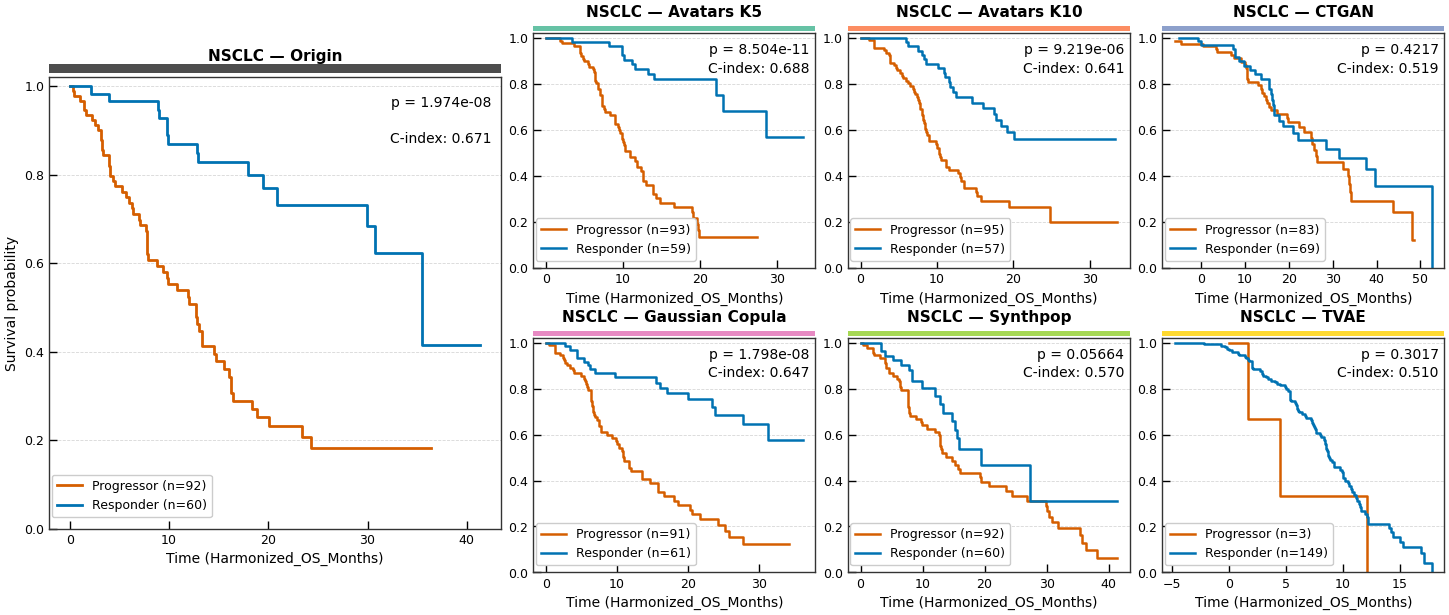

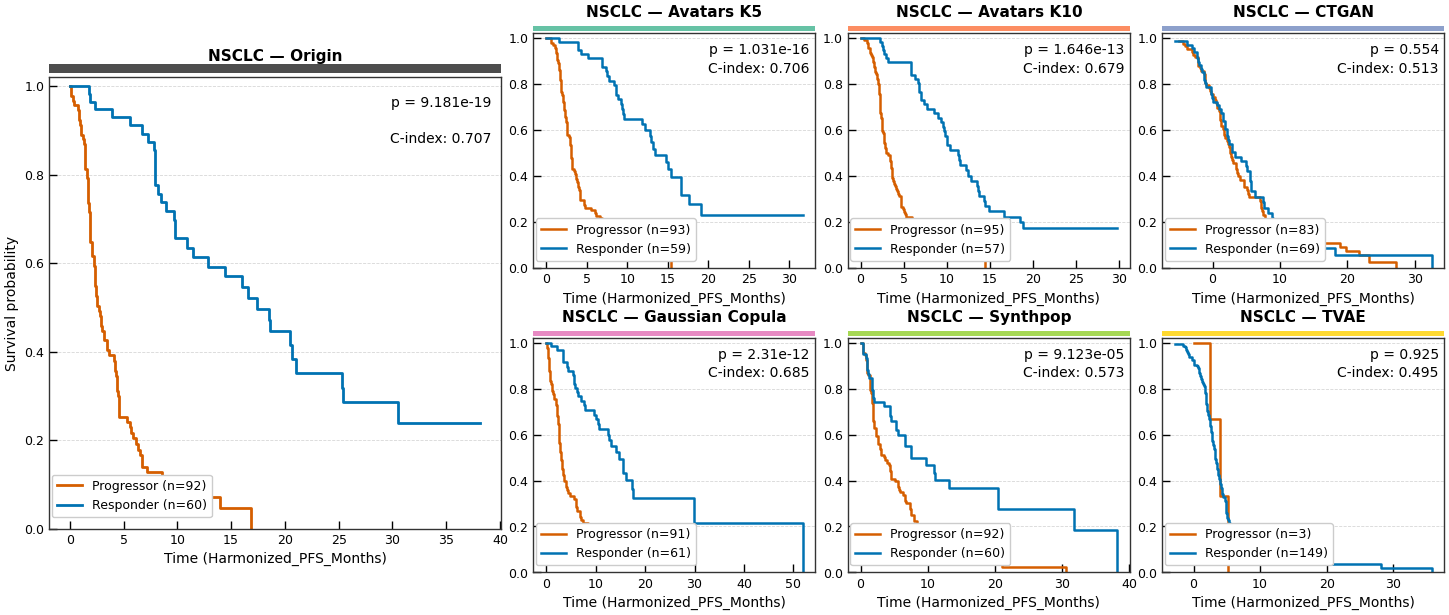

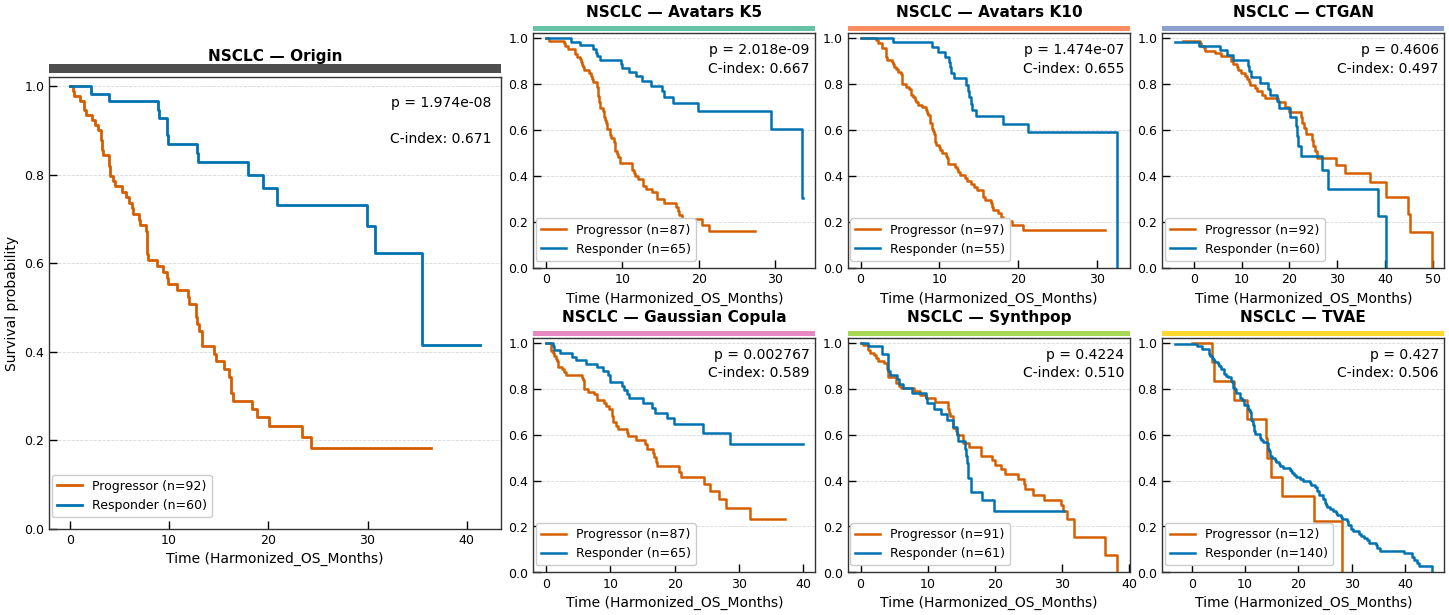

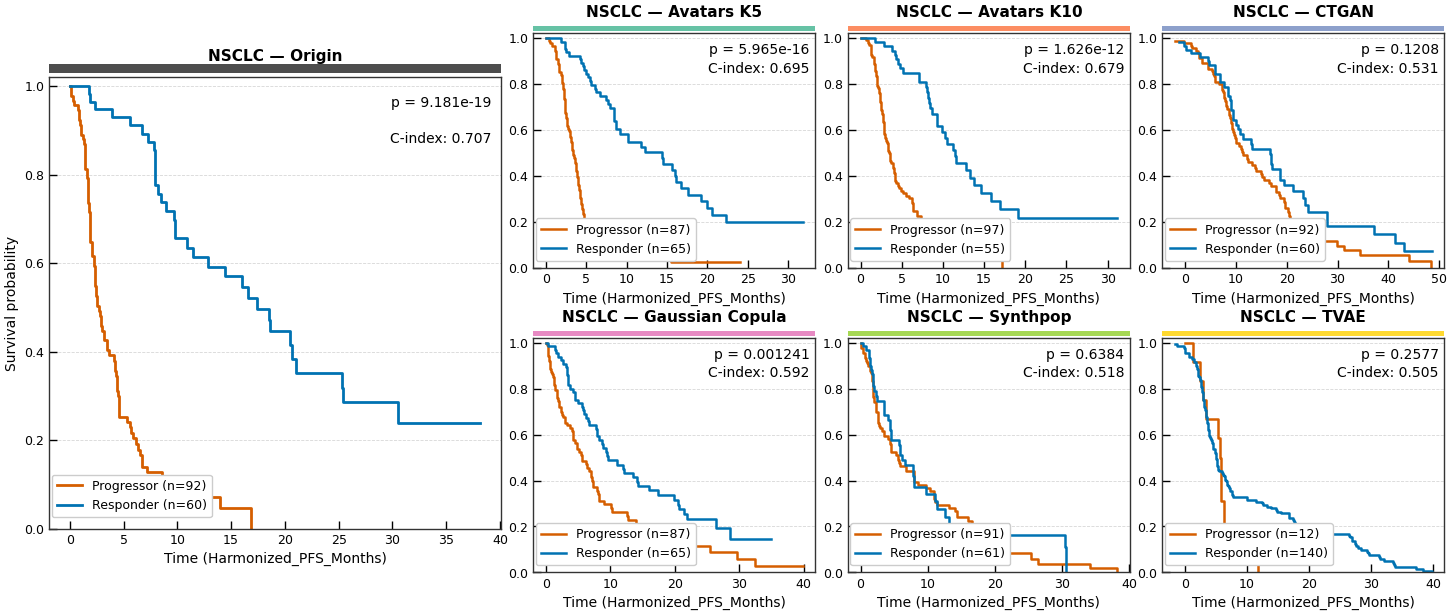

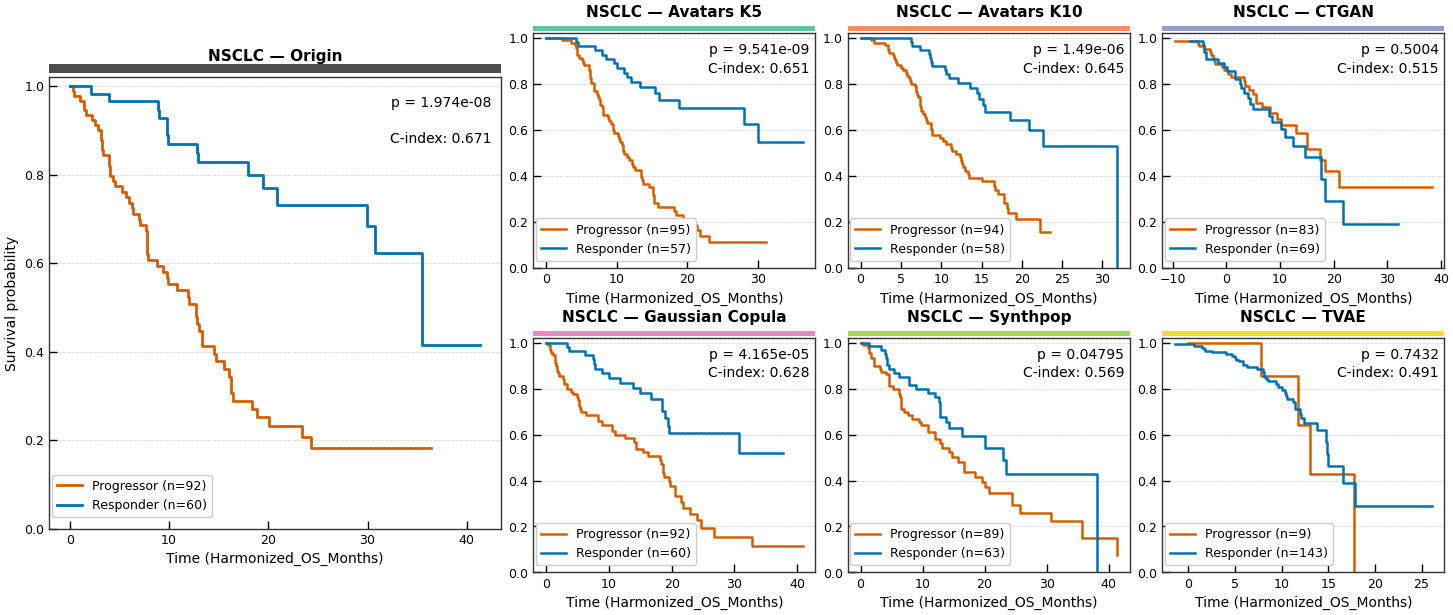

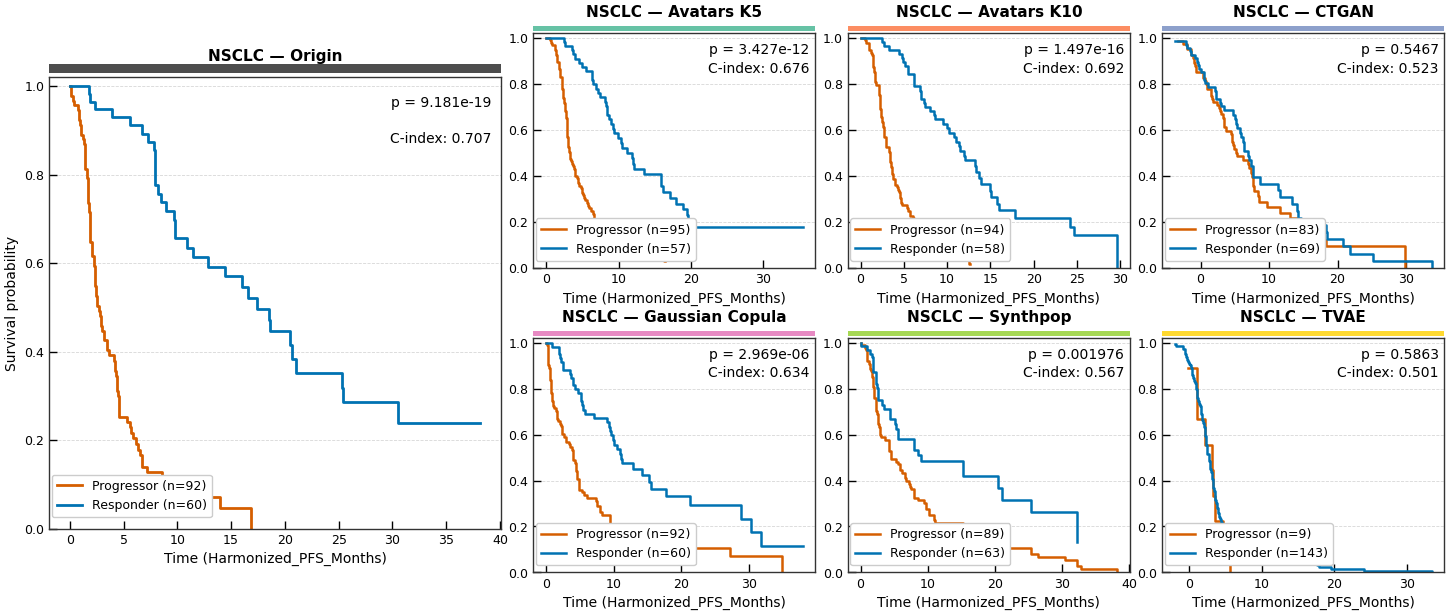

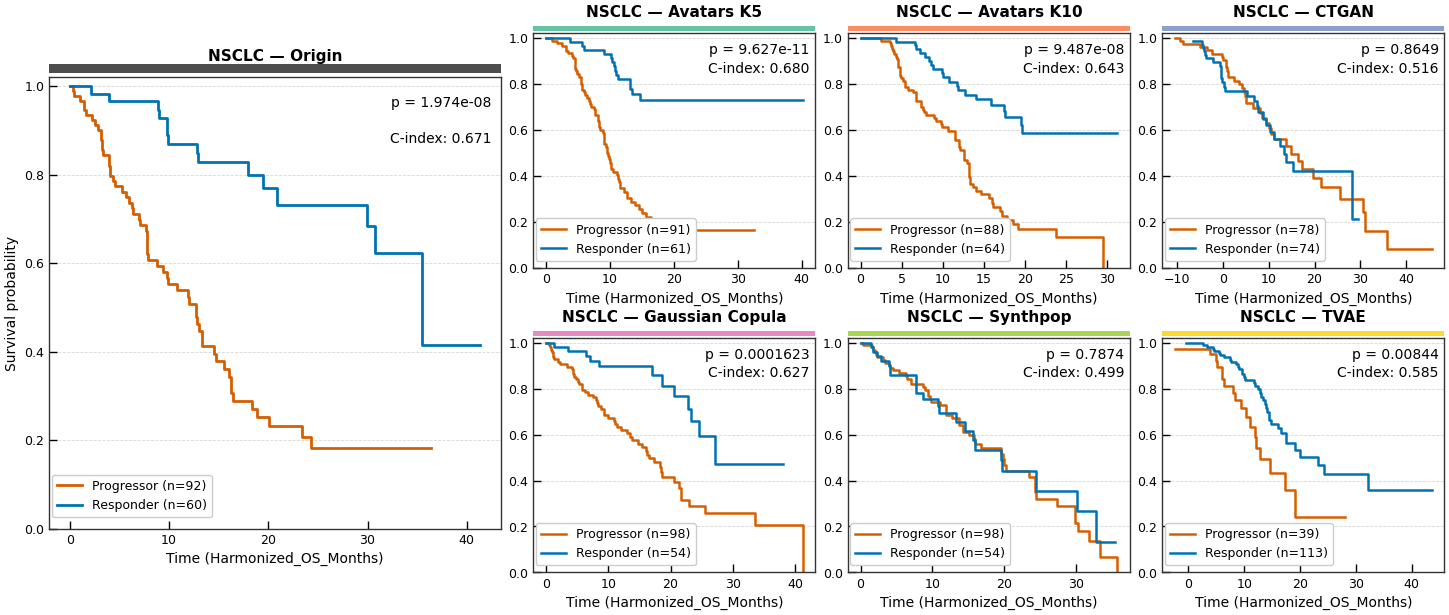

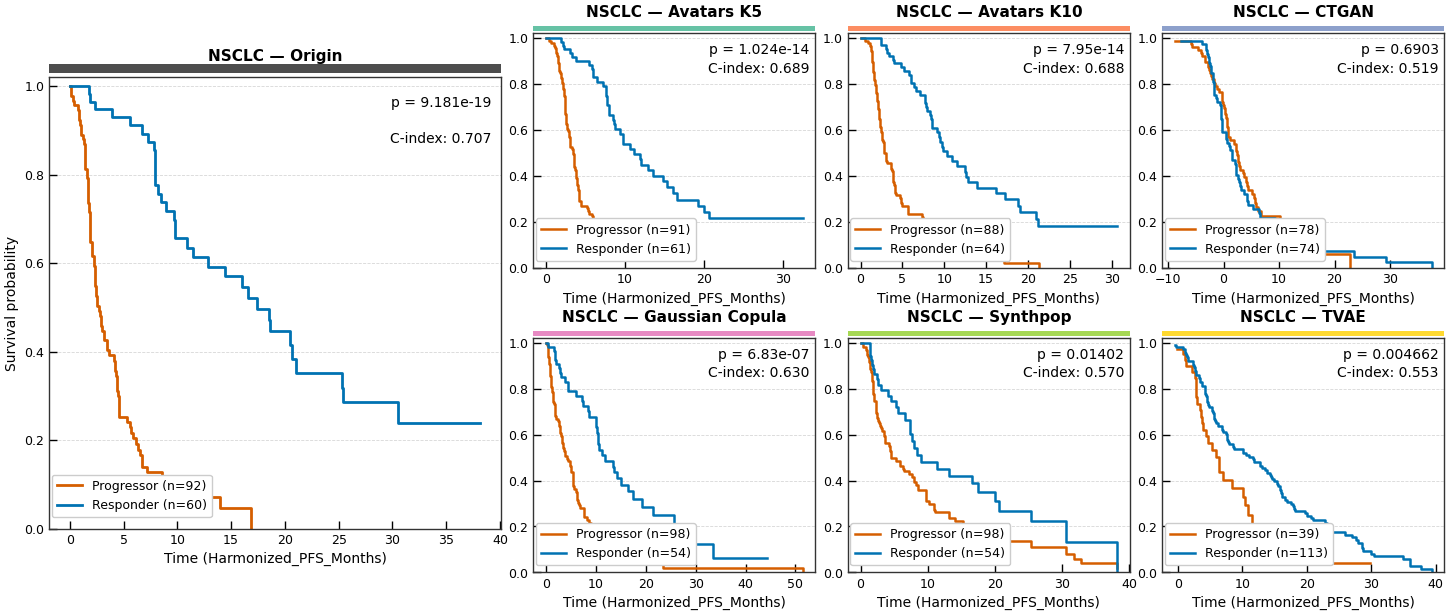

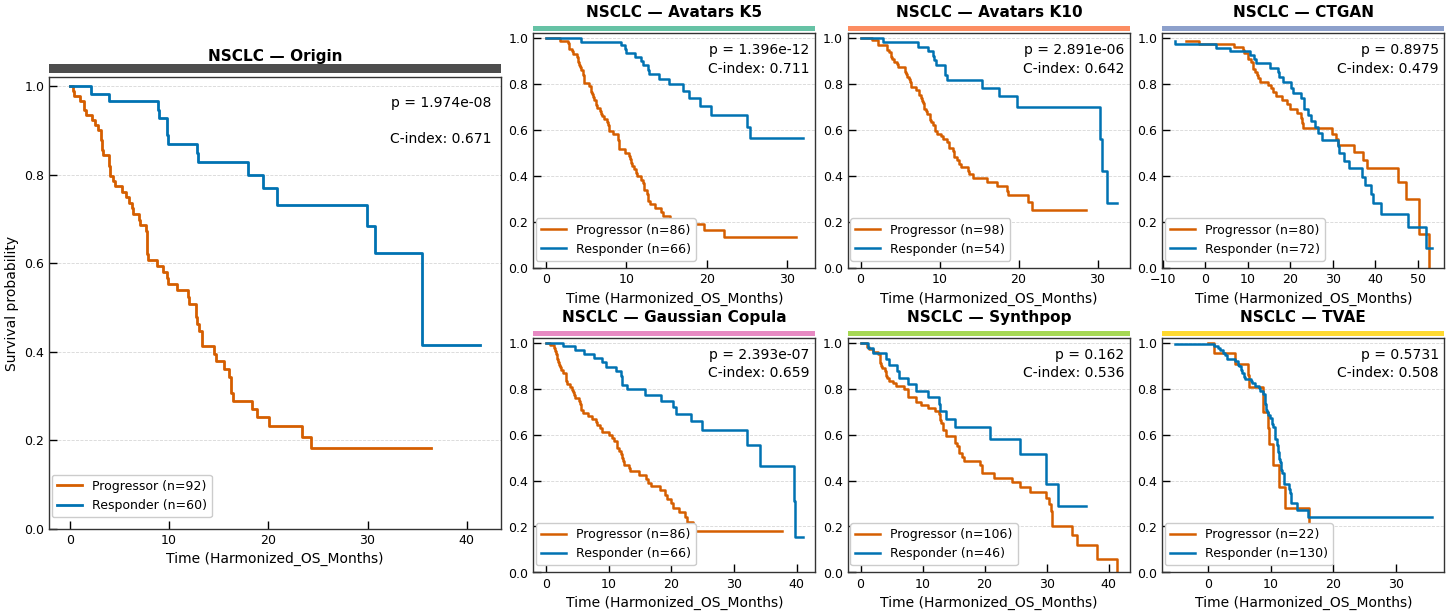

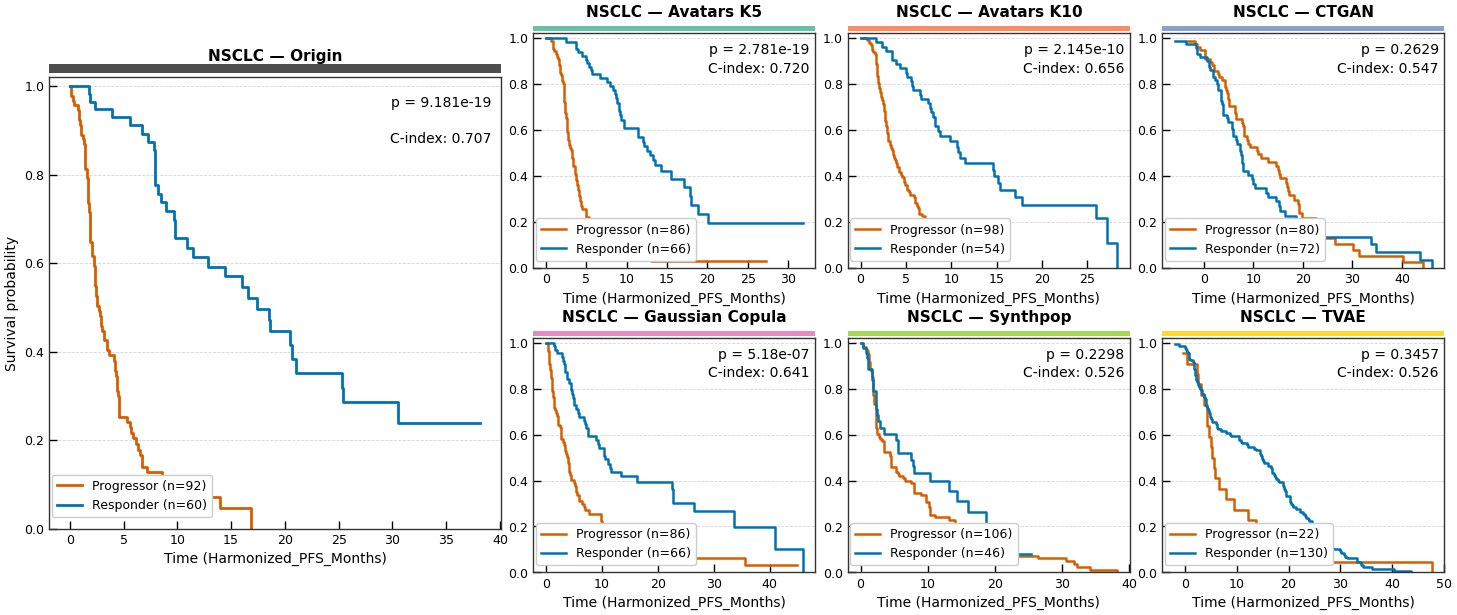

In [7]:
import pandas as pd
import numpy as np
from SynOmics.metrics.narrow_utility.survival_analysis import  SurvivalEvaluator
import warnings
warnings.filterwarnings("ignore")

dataset_dict = {}
original_data = pd.read_csv("../../Data/original_data.csv", index_col = 0)
responderCrit = original_data['Harmonized_Confirmed_BOR_3_Cat'].isin(['CR/PR'])
progressorCrit = original_data['Harmonized_Confirmed_BOR_3_Cat'].isin(['PD','SD'])

responders = original_data[responderCrit].index
progressors = original_data[progressorCrit].index

original_data.loc[responders,"Labels"] = 'Responder'
original_data.loc[progressors,"Labels"] = 'Progressor'
dataset_dict["Origin"] = original_data
seeds = [0,1,2,3,42]
for seed in seeds:
    syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
    names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
    synthetic_data_dictionary = {}
    for i, tool in enumerate(syn_datas):
        syn_df = pd.read_csv(f"../../Data/{syn_datas[i]}.csv", index_col = 0)
        responderCrit = syn_df['Harmonized_Confirmed_BOR_3_Cat'].isin(['CR/PR'])
        progressorCrit = syn_df['Harmonized_Confirmed_BOR_3_Cat'].isin(['PD','SD'])
        
        responders = syn_df[responderCrit].index
        progressors = syn_df[progressorCrit].index
        
        syn_df.loc[responders,"Labels"] = 'Responder'
        syn_df.loc[progressors,"Labels"] = 'Progressor'
        dataset_dict[names[i]] = syn_df

    phenotype = {"Labels": ["Responder", "Progressor"]}

    evaluator = SurvivalEvaluator(
        datasets_dict=dataset_dict,
        phenotype=phenotype,
        time_target="Harmonized_OS_Months",
        event_target="Harmonized_OS_Event",
        font_scale=1.0,
        is_pdf = False
    )
    # Compute C-index similarity scores with respect to Origin
    summary_df = evaluator.compute_survival_metrics()
    scored = evaluator.compute_cindex_scores(original_name="Origin")
    scored.to_csv(f'SurvivalAnalysis/OS/Seed_{seed}/score_os.csv')
    
    # Plot grid (and save individual plots)
    fig, summary = evaluator.plot_grid(
        figsize=(18,7), show_censors=False, ci_show=False, title_prefix="NSCLC", 
        save_dir=f"SurvivalAnalysis/OS/Seed_{seed}/"  # Folder to save each dataset's KM plot
    )
    fig.savefig(f'SurvivalAnalysis/OS/Seed_{seed}/Grid_KM_OS.png', dpi=300, bbox_inches='tight')


    # PFS
    # phenotype = {"Benefit": ["CB", "NCB"]}
    evaluator_pfs = SurvivalEvaluator(
        datasets_dict=dataset_dict,
        phenotype=phenotype,
        time_target="Harmonized_PFS_Months",
        event_target="Harmonized_PFS_Event",
        font_scale=1.0,
        is_pdf = False
    )
    # Compute C-index similarity scores with respect to Origin
    summary_df_pfs = evaluator_pfs.compute_survival_metrics()
    scored_pfs = evaluator_pfs.compute_cindex_scores(original_name="Origin")
    scored_pfs.to_csv(f'SurvivalAnalysis/PFS/Seed_{seed}/score_pfs.csv')
    
    # Plot grid (and save individual plots)
    fig_pfs, summary = evaluator_pfs.plot_grid(
        figsize=(18,7), show_censors=False, ci_show=False, title_prefix="NSCLC", 
        save_dir=f"SurvivalAnalysis/PFS/Seed_{seed}/"  # Folder to save each dataset's KM plot
    )
    
    fig_pfs.savefig(f'SurvivalAnalysis/PFS/Seed_{seed}/Grid_KM_PFS.png', dpi=300, bbox_inches='tight')

    

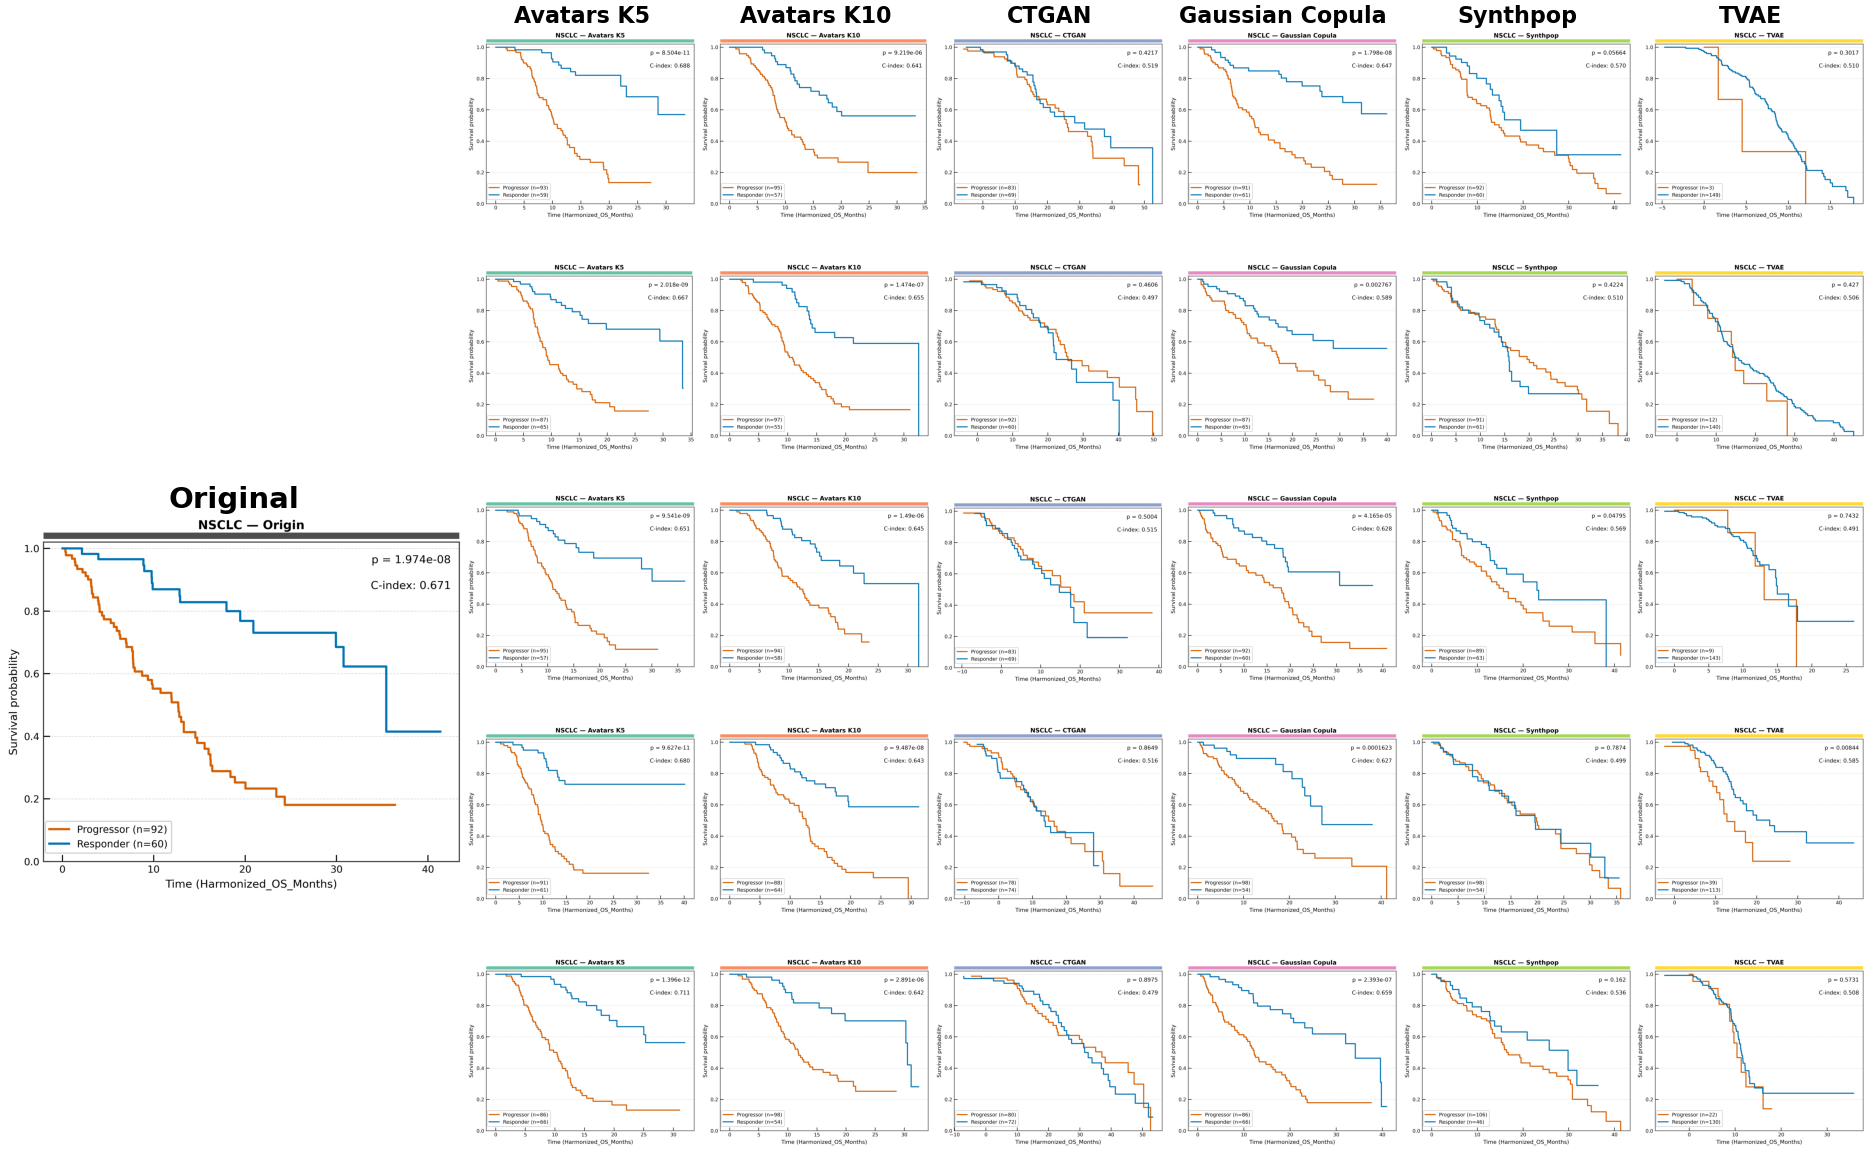

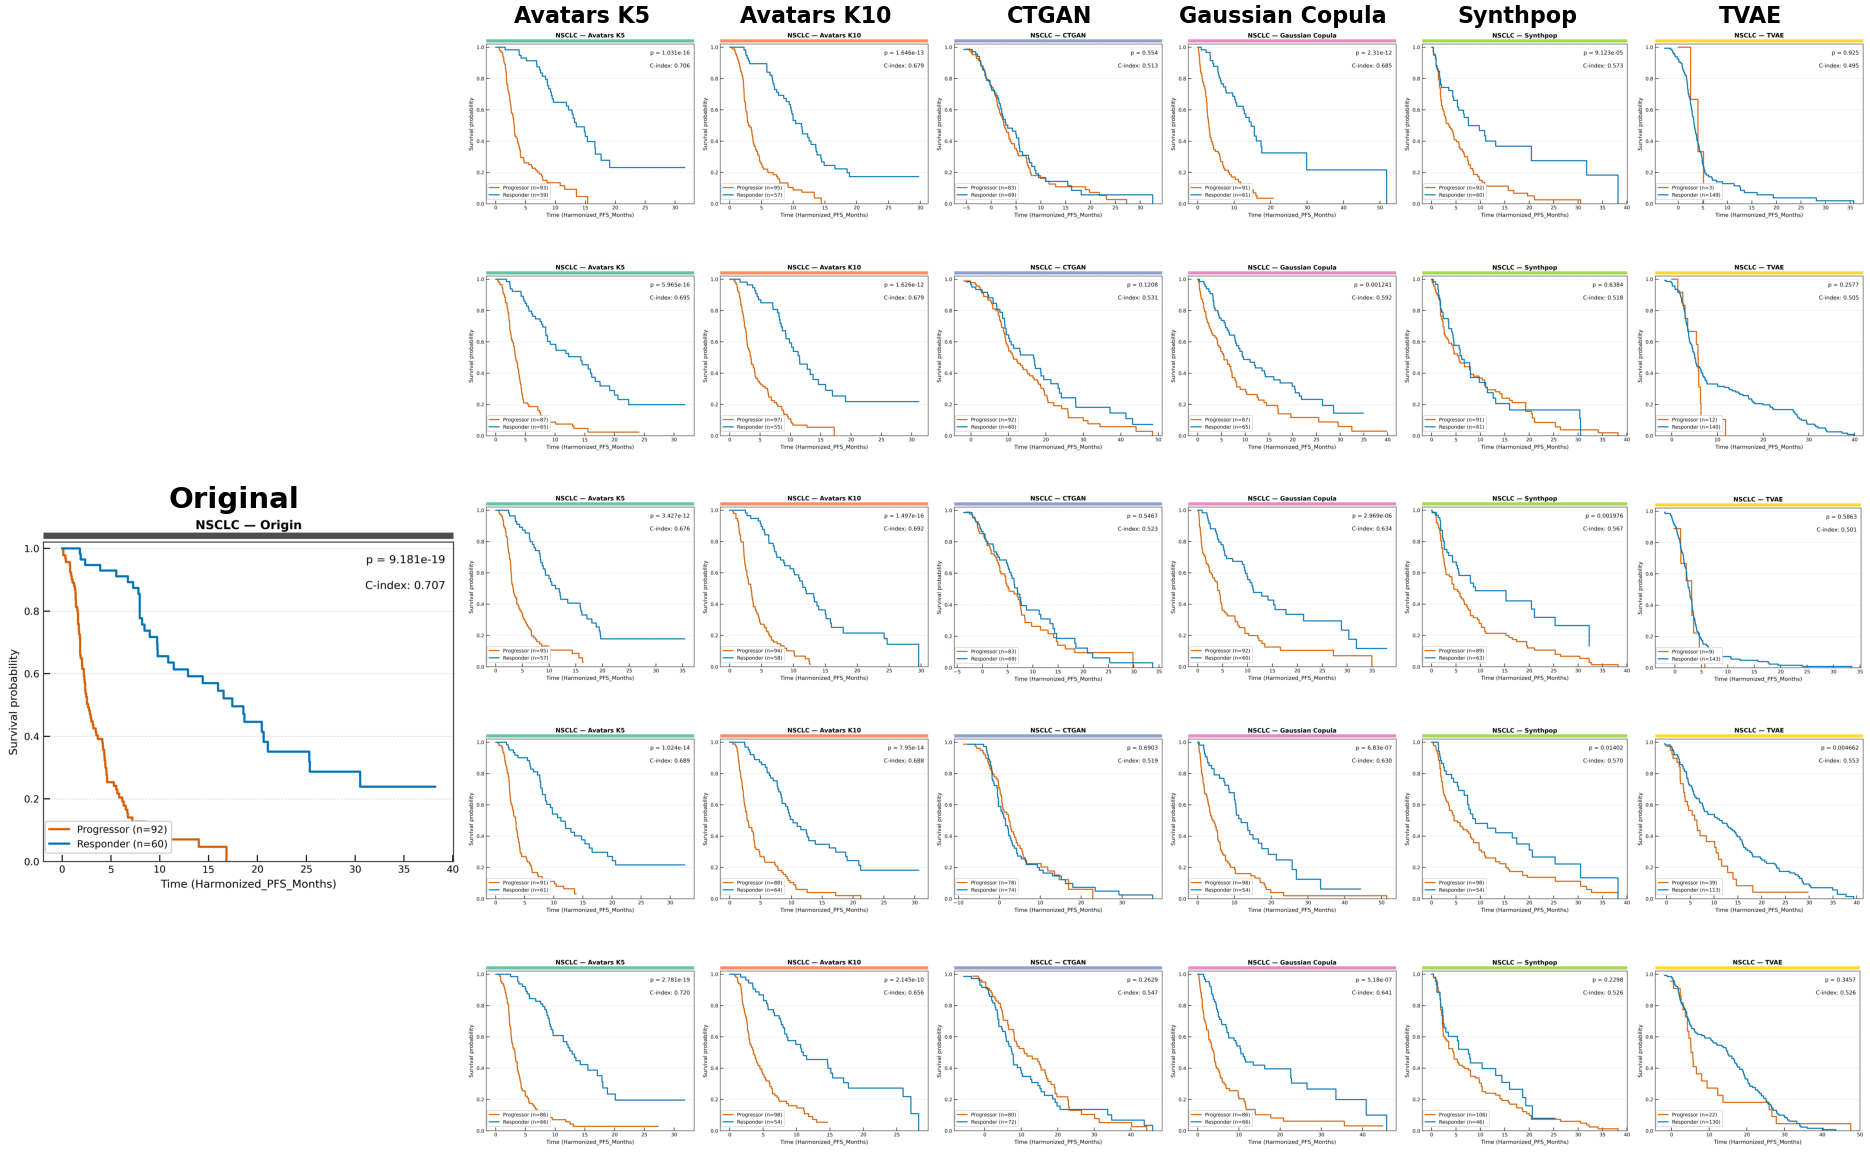

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import gridspec
import os

def combine_km_png_grid(
    original_png_path: str,
    synthetic_png_base: str,
    seeds: list,
    methods: list,
    output_path: str
):
    # Load Original
    images_orig = mpimg.imread(original_png_path)

    # Load Synthetic PNGs
    images_syn = []
    for method in methods:
        col_imgs = []
        for seed in seeds:
            method_png = synthetic_png_base.format(seed=seed, method=method)
            if not os.path.exists(method_png):
                raise FileNotFoundError(f"Missing PNG: {method_png}")
            col_imgs.append(mpimg.imread(method_png))
        images_syn.append(col_imgs)

    # Create big grid
    fig = plt.figure(figsize=(24, 18))
    gs = gridspec.GridSpec(
        6, 7,
        width_ratios=[3.2, 1.6, 1.6, 1.6, 1.6, 1.6, 1.6],
        height_ratios=[1]*6,
        wspace=0.02,
        hspace=0.02
    )

    # Original (spans all rows col=0)
    ax_orig = plt.subplot(gs[:, 0])
    ax_orig.imshow(images_orig)
    ax_orig.set_title("Original", fontsize=21, fontweight="bold")
    ax_orig.axis("off")

    # Synthetic panels (6x5)
    for col, method in enumerate(methods):
        for row, seed in enumerate(seeds):
            ax = plt.subplot(gs[row, col+1])
            ax.imshow(images_syn[col][row])
            if row == 0:
                ax.set_title(method, fontsize=16, fontweight="bold")
            if col == 0:
                ax.set_ylabel(f"Seed {seed}", fontsize=14, fontweight="bold")
            ax.axis("off")

    fig.tight_layout()
    fig.savefig(output_path, dpi=400, bbox_inches='tight')
    plt.show()

combine_km_png_grid(
    original_png_path="SurvivalAnalysis/OS/Seed_0/Origin_KMcurve.png",
    synthetic_png_base="SurvivalAnalysis/OS/Seed_{seed}/{method}_KMcurve.png",
    seeds=seeds,
    methods=names,
    output_path="SurvivalAnalysis/OS/Combined_KMGrid.png"
)

combine_km_png_grid(
    original_png_path="SurvivalAnalysis/PFS/Seed_0/Origin_KMcurve.png",
    synthetic_png_base="SurvivalAnalysis/PFS/Seed_{seed}/{method}_KMcurve.png",
    seeds=seeds,
    methods=names,
    output_path="SurvivalAnalysis/PFS/Combined_KMGrid.png"
)